# Import All Libraries


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import random
from PIL import Image

# Loading Dataset From Keras

In [5]:
# (train_images,train_labels),(train_images,train_labels)
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Image: AxesImage(shape=(28, 28))
Label: 5


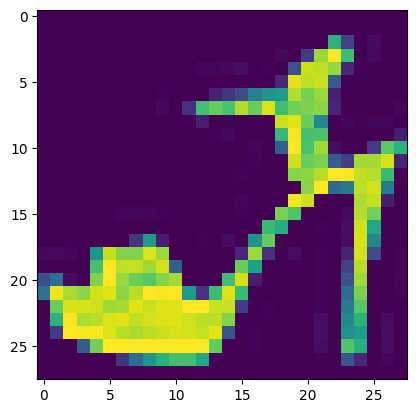

In [6]:
print(f'Image: {plt.imshow(x_train[9])}')

print(f'Label: {y_train[9]}')

Image: AxesImage(shape=(28, 28))
Label: 5


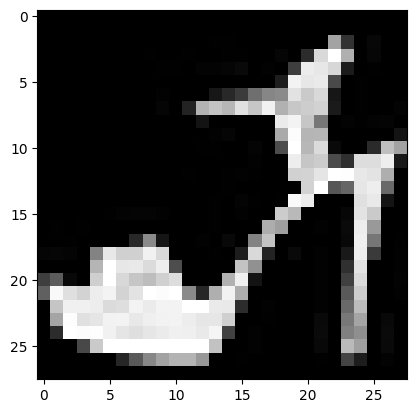

In [7]:
print(f'Image: {plt.imshow(x_train[9],cmap='gray')}')

print(f"Label: {y_train[9]}")

# Display Some Sample Images

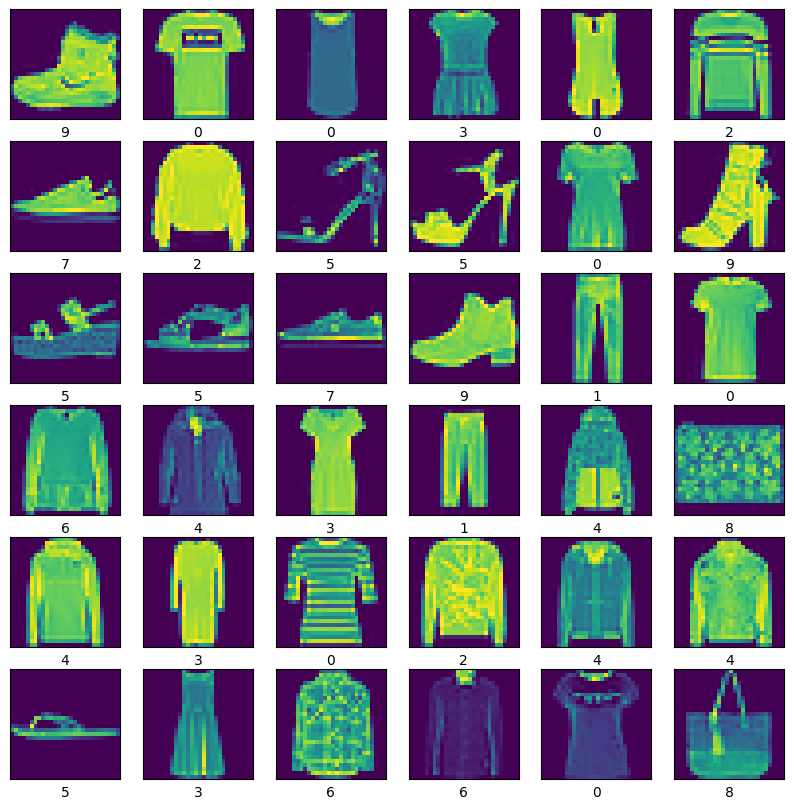

In [8]:
plt.figure(figsize=(10,10))
for i in range(36):
  plt.subplot(6,6,i+1)
  plt.imshow(x_train[i])
  plt.xlabel(y_train[i])
  plt.xticks([])
  plt.yticks([])
plt.show()

# Exploratory Data Analysis (EDA)

In [9]:
print(f"""WE Have {len(x_train)} images in train data and {len(x_test)} images in test data.
SImilarly,
We Have {len(y_train)} labels in Train Data and {len(y_test)} labels in Test data.

The size of each image Present in Train and Test data is {x_train[0].shape}""")

WE Have 60000 images in train data and 10000 images in test data.
SImilarly,
We Have 60000 labels in Train Data and 10000 labels in Test data.

The size of each image Present in Train and Test data is (28, 28)


In [10]:
x_train.shape # shape of x_train

(60000, 28, 28)

In [11]:
x_test.shape # Shape of x_test

(10000, 28, 28)

In [12]:
y_train.shape #shape of y_train

(60000,)

In [13]:
y_test.shape #shape of y_test

(10000,)

# Printing Random Images From Data





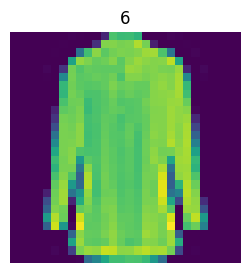

In [14]:
random_images = np.random.randint(len(x_train))
plt.figure(figsize=(3,3))
plt.imshow(x_train[random_images])
plt.title(y_train[random_images])
plt.axis(False)
plt.show()

# Displaying The image With Their Each Pixel Value

Image:


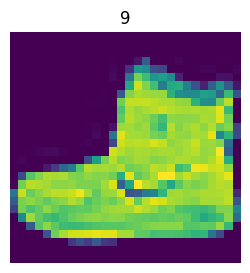

Pixel Value:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3 
  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15 
  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66 
  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 223 215

In [15]:
# Display The First Image
print('Image:')
plt.figure(figsize=(3,3))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.axis(False)
plt.show()


print('Pixel Value:')
for row in x_train[0]:
  for pixel in row:
    print('{:3}'.format(pixel),end= " ")
  print()


# Reshape The Data To Include Color Argument
it is not color image,it relly in gray scale color category so their color argument will be "1".if the image belongs to RGB Ctegory than the color argumnet will be "3".

Note: The color image Dataset which have color argument "3" are kn
kown as high dimenstional dataset and it takes much time for preprocessing

In [16]:
# Reshap the image
x_train = x_train.reshape(x_train.shape+(1,))
x_test = x_test.reshape(x_test.shape+(1,))

x_train.shape,x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# Normalizing Tha Data
Neural Network performs betteron Normalized data.Normalization turns the data into the same scale,in our case, between 0 and 1.

In the case of image,the normalization depends upon the maximum of the pixels which is 8 bit. in simplt words,each pixles value must be present between (0-255) range.so we directly take the ratio of the images 255, that sets all the images pixles values in between 0 to 1 that is more suitable for model to perform accurately.

In [17]:
x_train=x_train/255.0
x_test=x_test/255.0

# Changing Tha DataType

In [18]:
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')

# Displaying The Image With Their Each Pixel Value After Normalization

Image:


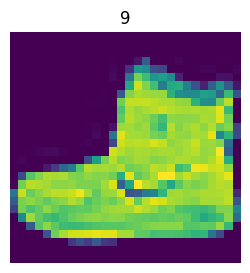

0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.004 0.000 0.000 0.051 0.286 0.000 0.000 0.004 0.016 0.000 0.000 0.000 0.000 0.004 0.004 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.012 0.000 0.141 0.533 0.498 0.243 0.212 0.000 0.000 0.000 0.004 0.012 0.016 0.000 0.000 0.012 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.024 0.000 0.400 0.800 0.690 0.525 0.565 0.482 0.090 0.000 0.000 0.000 0.000 0.047

/tmp/ipykernel_1877/4031891116.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('{:0.3f}'.format(float(pixel)),end=" ")


In [19]:
print('Image:')
plt.figure(figsize=(3,3))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.axis(False)
plt.show()

for row in x_train[0]:
  for pixel in row:
    print('{:0.3f}'.format(float(pixel)),end=" ")
  print()

# Data Modeling With CNN

In [20]:
model=tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.InputLayer(input_shape=(28,28,1)),

    #hidden Layer

    #filter is the numbers filters we want to apply
    #kernel is the size of filter moving over the image
    # 1st Layer CNN
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    # Normalize the input of a layer in a neural networks
    tf.keras.layers.BatchNormalization(),
    # Dropout is a Regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),


    # 2st Layer CNN
    tf.keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    # Normalize the input of a layer in a neural networks
    tf.keras.layers.BatchNormalization(),
    # Dropout is a Regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),

    # 3st Layer CNN
    tf.keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    # Normalize the input of a layer in a neural networks
    tf.keras.layers.BatchNormalization(),
    # Dropout is a Regularization technique use to prevent overfitting
    tf.keras.layers.Dropout(0.2),


    tf.keras.layers.Flatten(),#Flattenlayer

    #Output Layer
    tf.keras.layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,858 (370.54 KB)

 Trainable params: 94,410 (368.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [23]:
history=model.fit(x_train,y_train,epochs=5,batch_size=100,validation_split=0.2)

Epoch 1/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.7884 - loss: 0.5914 - val_accuracy: 0.6337 - val_loss: 0.9458
Epoch 2/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 60s 126ms/step - accuracy: 0.8467 - loss: 0.4196 - val_accuracy: 0.8678 - val_loss: 0.3556
Epoch 3/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 57s 118ms/step - accuracy: 0.8632 - loss: 0.3753 - val_accuracy: 0.8767 - val_loss: 0.3327
Epoch 4/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 58s 121ms/step - accuracy: 0.8750 - loss: 0.3417 - val_accuracy: 0.8767 - val_loss: 0.3277
Epoch 5/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 57s 119ms/step - accuracy: 0.8790 - loss: 0.3284 - val_accuracy: 0.8831 - val_loss: 0.3147


# Graph Representation Loss & Accuracy

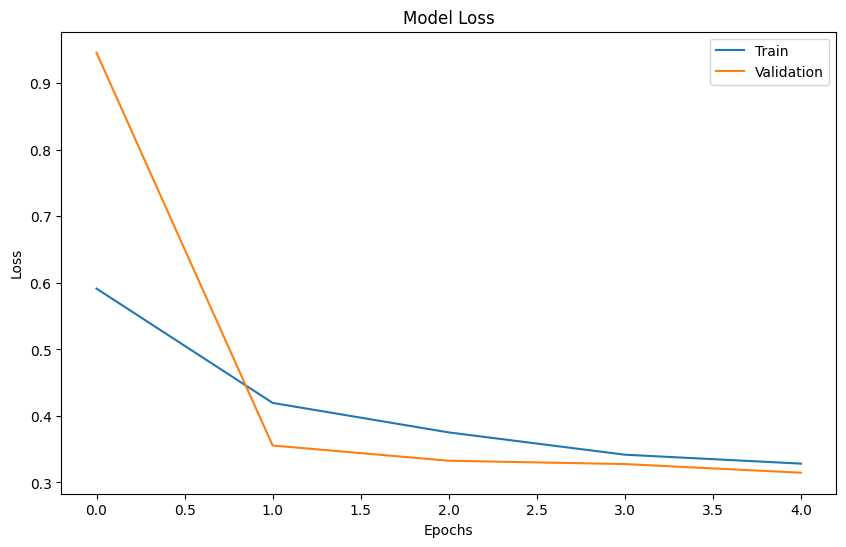

In [24]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

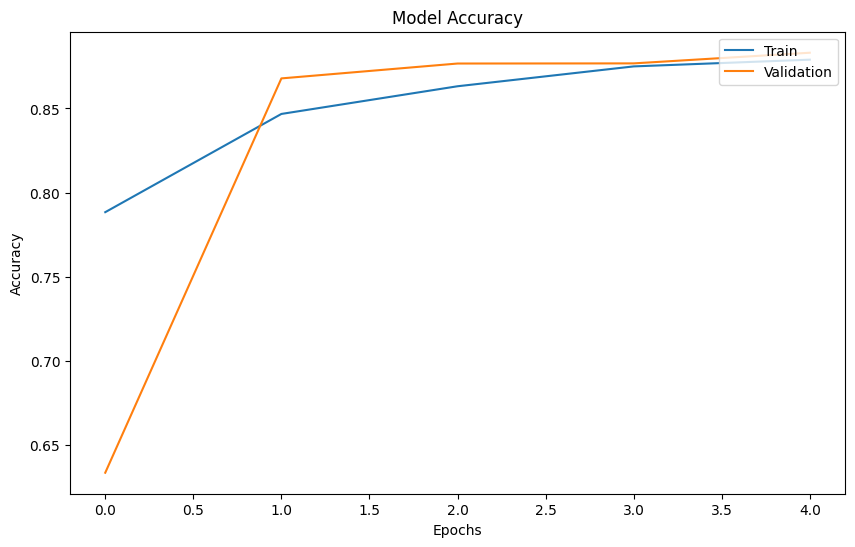

In [25]:
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

# Model Evaluation For Loss & Accuracy On Test Data

In [26]:
loss,accuracy=model.evaluate(x_test,y_test)
print(f"Model Loss:",{loss*100})
print(f"Model Accuracy:",{accuracy*100})

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8775 - loss: 0.3289
Model Loss: {32.88523256778717}
Model Accuracy: {87.74999976158142}


# Prediction

In [27]:
predictions = model.predict(x_test)

print("Predicted class:", predictions[0].argmax())
print("Actual class:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Predicted class: 9
Actual class: 9


In [28]:
model.save('fashion_model.h5')